# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# Run 2: Sample CORSIKA Primaries with Height

This notebook samples primary events from the HDF5 model generated by `run1_CosmicRay_Model.ipynb`.

- Each sampled row includes species, energy, zenith angle, azimuth, and the CORSIKA observation level $h$ .

- The resulting primary table is intended to drive a large CORSIKA campaign. Each row contains the species, energy, direction, bin indices, and primary weight needed to map the simulated showers back to the physical cosmic-ray distribution.

## 1. Libraries

This section imports the numerical, plotting, tabular, and HDF5 libraries used to sample CORSIKA primary events from the model built in Run 1.

In [8]:
from __future__ import annotations
%matplotlib inline

import os
import random

from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.notebooks.notebookConfig import load_notebook_config

plt.style.use("seaborn-v0_8-whitegrid")



In [9]:
# Section 1 smoke test: verify that the scientific stack was imported.
print(f"NumPy version: {np.__version__}")
print(f"h5py version: {h5py.__version__}")
print(f"Pandas version: {pd.__version__}")
assert np.__version__
assert h5py.__version__
assert plt is not None

# Section 1 diagnostic: report imported plotting backend and optional CRFlux availability.
print(f"\nMatplotlib inline rendering is enabled in notebooks.")
print(f"Configured style: seaborn-v0_8-whitegrid")

print("\nSection 1 test passed: libraries are available.")

NumPy version: 1.26.4
h5py version: 3.14.0
Pandas version: 2.3.3

Matplotlib inline rendering is enabled in notebooks.
Configured style: seaborn-v0_8-whitegrid

Section 1 test passed: libraries are available.


## 2. Parameters

This section defines shared workflow paths and sampling options. The primary output can be written as CSV or Parquet, and the sampling mode controls whether events follow the physical flux directly or use importance sampling.

### 2.1 Paths

In [10]:
config = load_notebook_config()

PATH_CORSIKA_ROOT = "/home/juan/hep/opt/corsika8-install"
RUN = "run_test"

OUTPUT_ROOT = config.output_root
OUTPUT_DATA_ROOT = config.output_data_root
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "crf")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the original notebook code.
PATH_OUTPUT_ROOT = OUTPUT_ROOT
PATH_OUTPUT_CORSIKA = OUTPUT_CORSIKA_ROOT
PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_CORSIKA_GENERATOR.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
OUTPUT_DIR = PATH_OUTPUT_RUN
PATH_OUTPUT_RUN.mkdir(parents=True, exist_ok=True)

# Run 1 writes a per-execution seeded file crf_model_{SEED}.h5; load the most
# recently generated one.
_run1_models = sorted(PATH_OUTPUT_RUN.glob("crf_model_*.h5"), key=lambda p: p.stat().st_mtime)
if not _run1_models:
    raise FileNotFoundError(
        f"No Run 1 HDF5 model found in {PATH_OUTPUT_RUN}. Run run1_CosmicRay_Model.ipynb first."
    )
PATH_CRMODEL_FILE = _run1_models[-1]

print(" Configured workflow paths:\n", "=" * 80)
print(" - PATH_CORSIKA_ROOT = ", PATH_CORSIKA_ROOT)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - RUN = ", RUN, "\n")

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_RUN       = ", PATH_OUTPUT_RUN)
print(" - OUTPUT_DIR            = ", OUTPUT_DIR)
print(" - PATH_CRMODEL_FILE     = ", PATH_CRMODEL_FILE, "(latest Run 1 model)")



 Configured workflow paths:
 - PATH_CORSIKA_ROOT =  /home/juan/hep/opt/corsika8-install
 - OUTPUT_ROOT =  v:\output
 - OUTPUT_DATA_ROOT =  v:\output\data
 - OUTPUT_CORSIKA_ROOT =  v:\output\data\crf
 - RUN =  run_test 

 Output paths:
 - PATH_OUTPUT_RUN       =  v:\output\data\crf\generator\run_test
 - OUTPUT_DIR            =  v:\output\data\crf\generator\run_test
 - PATH_CRMODEL_FILE     =  v:\output\data\crf\generator\run_test\crf_model_117074994.h5 (latest Run 1 model)


### 2.2 Parameters and Configuration


### Importance Sampling

The primary table can be generated either from the physical cosmic-ray distribution or from a deliberately balanced proposal distribution. 

Let $$x = (s, E, \theta, \phi, h)$$ denote one **sampled primary state**, where 

- $s$ is the primary species,
- $E$ is the primary energy,
- $\theta$ and $\phi$ define the incoming direction
- $h$ is the observation height assigned to the event.

The **target distribution** $p(x)$ is the physical distribution encoded in the Run 1 HDF5 model. In this workflow it is factorized as 

$$p(x) = p(s,E)\,p(\theta)\,p(\phi)\,p(h)$$

- The term $p(s,E)$ comes from the CRFlux model integrated over the energy bins,
- $p(\theta)$ and $p(\phi)$ define the angular sampling,
- $p(h)$ is uniform because CRFlux itself does not depend on observation height.

The **proposal distribution** $q(x)$ is the distribution actually used to draw Monte Carlo events. When $q(x) \neq p(x)$, the generated sample is not physically distributed by itself, so each event receives an importance weight 

$$
w_i = \frac{p_{\mathrm{real}}(s_i, E_i, \theta_i, \phi_i)}{q_{\mathrm{sim}}(s_i, E_i, \theta_i, \phi_i)}.
$$

In the binned implementation used here, this becomes:

$$
w_i =
\frac{
P_{\mathrm{real}}(s, E_{\mathrm{bin}})\,
P_{\mathrm{real}}(\theta_{\mathrm{bin}})\,
P_{\mathrm{real}}(\phi_{\mathrm{bin}})
}{
P_{\mathrm{sim}}(s, E_{\mathrm{bin}})\,
P_{\mathrm{sim}}(\theta_{\mathrm{bin}})\,
P_{\mathrm{sim}}(\phi_{\mathrm{bin}})
}.
$$

For absolute flux estimates, the dimensionless ratio above is multiplied by the integrated physical normalization and divided by the number of simulated events:

$$
W_i = \frac{\Phi_{\mathrm{cone}}}{N_{\mathrm{events}}}\,
\frac{p_{\mathrm{real}}}{q_{\mathrm{sim}}}.
$$

where $\Phi_{\mathrm{cone}}$ is the cone-integrated flux normalization and $N$ is the number of generated primaries.

The key practical point is that high-energy showers must be simulated now. If high-energy primaries are missing from the CORSIKA campaign, the diffusion dataset cannot recover them later.


1. The option `physical` uses $q(x) = p(x)$. Events are sampled according to the physical cosmic-ray flux, so the correction is $w(x)=1$ apart from the global normalization. This is statistically natural but produces many low-energy events and comparatively few high-energy events.

2. The option `balanced_log_energy` makes the proposal approximately uniform over logarithmic energy bins while preserving the physical species mixture conditional on energy. In practice, $q(E)$ is flattened in log-energy space and $q(s\mid E)$ follows the physical model. The expected result is better coverage across the full energy range, especially at high energy, while still keeping realistic species proportions inside each energy bin.

3. The option `balanced_log_energy_species` makes the proposal uniform over both species and logarithmic energy bins, $q(s,E) = 1/(N_s N_E)$. This gives the strongest coverage of rare species and high-energy bins. The expected result is a more balanced simulation campaign for machine-learning dataset generation, but with more variable event weights because the generated events are farther from the physical distribution.

In all three cases, downstream flux estimates must use the stored event weights. The purpose of balancing is not to change the target physics $p(x)$, but to improve Monte Carlo coverage of the phase space used later by the diffusion model.

In [11]:
PRIMARY_SPECIES: dict[int, dict[str, object]] = {
    14:   {"mnemonic": "p",    "name": "proton",      "Z": 1,  "A": 1,  "pdg": 2212},
    402:  {"mnemonic": "He",   "name": "helium",      "Z": 2,  "A": 4,  "pdg": 0},
    1206: {"mnemonic": "C",    "name": "carbon",      "Z": 6,  "A": 12, "pdg": 0},
    1407: {"mnemonic": "N",    "name": "nitrogen",    "Z": 7,  "A": 14, "pdg": 0},
    1608: {"mnemonic": "O",    "name": "oxygen",      "Z": 8,  "A": 16, "pdg": 0},
    2412: {"mnemonic": "Mg",   "name": "magnesium",   "Z": 12, "A": 24, "pdg": 0},
    2613: {"mnemonic": "Al",   "name": "aluminium",   "Z": 13, "A": 26, "pdg": 0},
    2814: {"mnemonic": "Si",   "name": "silicon",     "Z": 14, "A": 28, "pdg": 0},
    5025: {"mnemonic": "Mn",   "name": "manganese",   "Z": 25, "A": 50, "pdg": 0},
    5426: {"mnemonic": "Fe54", "name": "iron-54",     "Z": 26, "A": 54, "pdg": 0},
    5626: {"mnemonic": "Fe56", "name": "iron-56",     "Z": 26, "A": 56, "pdg": 0},
    5427: {"mnemonic": "Co54", "name": "cobalt-54",   "Z": 27, "A": 54, "pdg": 0},
    }

# ============================================================
# CONSTANT PARAMETERS
# ============================================================

OUTPUT_FORMAT = "csv"
N_EVENTS = 1_000_000
N_PRIMARY_FILES = 1

RANDOM_SEEDS = [random.SystemRandom().randint(0, 2**31 - 1) for _ in range(N_PRIMARY_FILES)]
RANDOM_SEED = RANDOM_SEEDS[0]

SUPPORTED_SAMPLING_MODE = {"physical", "balanced_log_energy", "balanced_log_energy_species"}
SAMPLING_MODE = "physical"

@dataclass(frozen=True)
class SamplingConfig:
    """Configuration for primary-event sampling.

    Args:
        input_hdf5_path: HDF5 model created by Run 1.
        output_path: Primary table destination.
        output_format: File format, either `csv` or `parquet`.
        sampling_mode: Proposal distribution used for event generation.
        n_events: Number of primary events to generate.
        random_seed: Seed for deterministic sampling.
    """

    input_hdf5_path: Path = Path(PATH_CRMODEL_FILE)
    output_path: Path = Path(PATH_OUTPUT_RUN / f"crf_primary_{RANDOM_SEED}.csv")
    output_format: str = "csv"
    sampling_mode: str = "balanced_log_energy_species"
    n_events: int = 10_000
    random_seed: int = 12345

    @property
    def output_directory(self) -> Path:
        """Return the directory containing the primary table.

        Returns:
            Parent directory of `output_path`.
        """
        return self.output_path.parent

    @property
    def output_stem(self) -> str:
        """Return the primary table filename without extension.

        Returns:
            Stem of `output_path`.
        """
        return self.output_path.stem

CONFIG = SamplingConfig(
    input_hdf5_path=Path(PATH_CRMODEL_FILE),
    output_path=Path(PATH_OUTPUT_RUN / f"crf_primary_{RANDOM_SEED}.csv"),
    output_format=OUTPUT_FORMAT,
    sampling_mode=SAMPLING_MODE,
    n_events=N_EVENTS,
    random_seed=RANDOM_SEED,
)



### 2.3. Sanity Checks

In [12]:
assert CONFIG.output_format in {"csv", "parquet"}
assert CONFIG.sampling_mode in SUPPORTED_SAMPLING_MODE
assert N_PRIMARY_FILES > 0
assert len(RANDOM_SEEDS) == N_PRIMARY_FILES
assert len(set(RANDOM_SEEDS)) == N_PRIMARY_FILES

# Section 2 diagnostic: verify the selected paths and sampling controls.
print("\nMulti-file generation")
print("-" * 72)
print(f"N_PRIMARY_FILES: {N_PRIMARY_FILES}")
print(f"RANDOM_SEEDS:    {RANDOM_SEEDS}")

print("\nSupported sampling modes:")
print("-" * 72)
for mode in sorted(SUPPORTED_SAMPLING_MODE):
    print(f"- {mode}")
print(f"\nSelected Sampling mode:  {CONFIG.sampling_mode}")
print("Importance correction used later: w = p(x) / q(x)")

assert CONFIG.output_path.suffix == f".{CONFIG.output_format}"
print("\nPrimary-sampling configuration (file 1 template)")
print("-" * 72)
for field_name in CONFIG.__dataclass_fields__:
    print(f"{field_name:>18}: {getattr(CONFIG, field_name)}")

print("\nPrimary species catalog")
print("-" * 72)
for corsika_id, species in PRIMARY_SPECIES.items():
    print(
        f"CORSIKA ID {corsika_id:>4}: "
        f"{species['mnemonic']:<4} | {species['name']:<9} | "
        f"Z={species['Z']:>2} A={species['A']:>2} PDG={species['pdg']}"
    )





Multi-file generation
------------------------------------------------------------------------
N_PRIMARY_FILES: 1
RANDOM_SEEDS:    [877549497]

Supported sampling modes:
------------------------------------------------------------------------
- balanced_log_energy
- balanced_log_energy_species
- physical

Selected Sampling mode:  physical
Importance correction used later: w = p(x) / q(x)

Primary-sampling configuration (file 1 template)
------------------------------------------------------------------------
   input_hdf5_path: v:\output\data\crf\generator\run_test\crf_model_117074994.h5
       output_path: v:\output\data\crf\generator\run_test\crf_primary_877549497.csv
     output_format: csv
     sampling_mode: physical
          n_events: 1000000
       random_seed: 877549497

Primary species catalog
------------------------------------------------------------------------
CORSIKA ID   14: p    | proton    | Z= 1 A= 1 PDG=2212
CORSIKA ID  402: He   | helium    | Z= 2 A= 4 PDG=0
CORS

## 3. Distribution Loading

This section reads the HDF5 model generated by Run 1 and exposes the species, energy, angular, and height probability tables used by the sampler.

In [13]:
def load_model(path: Path) -> dict[str, Any]:
    """Load the Run 1 HDF5 primary model.

    Args:
        path: HDF5 file containing grid and probability tables.

    Returns:
        Dictionary with species, energy, angular, height, and normalization arrays.
    """
    with h5py.File(path, "r") as h5:
        model = {
            "energy_edges": h5["energy/edges_gev"][:],
            "corsika_ids": h5["species/corsika_ids"][:].astype(np.int32),
            "species_energy_probability": h5["model/species_energy_probability"][:],
            "species_probability": h5["species/probability"][:],
            "energy_probability":  h5["model/energy_probability"][:],
            "species_energy_cdf": h5["model/species_energy_cdf"][:],
            "theta_edges_deg": h5["angle/theta/edges_deg"][:],
            "theta_probability": h5["angle/theta/probability"][:],
            "theta_cdf": h5["angle/theta/cdf"][:],
            "phi_edges_deg": h5["angle/phi/edges_deg"][:],
            "phi_probability": h5["angle/phi/probability"][:],
            "phi_cdf": h5["angle/phi/cdf"][:],
            "h_edges_m": h5["height/edges_m"][:],
            "h_probability": h5["height/probability"][:],
            "h_cdf": h5["height/cdf"][:],
            "cone_integrated_flux": float(h5["model/cone_integrated_flux"][()]),
        }
    return model


MODEL = load_model(CONFIG.input_hdf5_path)
print("Loaded Model:", CONFIG.input_hdf5_path)
print("\nAvailable Arrays:")
print("-" * 72)
for name, array in MODEL.items():
    if name != "cone_integrated_flux":
        print(f"{name:<26} | {str(list(array.shape)):<10} | {array.min():.4f} | {array.max():.3f}")
print("\nPrimary Availables")
print("-" * 72)
for corsika_id in MODEL["corsika_ids"].tolist():
    species = PRIMARY_SPECIES.get(int(corsika_id), {"mnemonic": "?", "name": "unknown", "Z": "?", "A": "?", "pdg": "?"})
    print(
        f"CORSIKA ID {int(corsika_id):>4}: "
        f"{species['mnemonic']:<4} | {species['name']:<9} | "
        f"Z={species['Z']} A={species['A']} PDG={species['pdg']}"
    )

Loaded Model: v:\output\data\crf\generator\run_test\crf_model_117074994.h5

Available Arrays:
------------------------------------------------------------------------
energy_edges               | [1002]     | 100.0000 | 1000000.000
corsika_ids                | [11]       | 14.0000 | 5427.000
species_energy_probability | [11, 1001] | 0.0000 | 0.007
species_probability        | [11]       | 0.0004 | 0.438
energy_probability         | [1001]     | 0.0000 | 0.015
species_energy_cdf         | [11011]    | 0.0068 | 1.000
theta_edges_deg            | [91]       | 0.0000 | 89.000
theta_probability          | [90]       | 0.0002 | 0.018
theta_cdf                  | [90]       | 0.0002 | 1.000
phi_edges_deg              | [362]      | 0.0000 | 360.000
phi_probability            | [361]      | 0.0028 | 0.003
phi_cdf                    | [361]      | 0.0028 | 1.000
h_edges_m                  | [202]      | 0.0000 | 100000.000
h_probability              | [201]      | 0.0050 | 0.005
h_cdf          

In [14]:
# Section 3 diagnostic: validate loaded probability tables.
print("Species-energy probability sum:", MODEL["species_energy_probability"].sum())
print("Theta probability sum:", MODEL["theta_probability"].sum())
print("Phi probability sum:", MODEL["phi_probability"].sum())
print("Height probability sum:", MODEL["h_probability"].sum())
assert np.isclose(MODEL["species_energy_probability"].sum(), 1.0)
assert np.isclose(MODEL["theta_probability"].sum(), 1.0)
assert np.isclose(MODEL["phi_probability"].sum(), 1.0)
assert np.isclose(MODEL["h_probability"].sum(), 1.0)


Species-energy probability sum: 1.0000000000000002
Theta probability sum: 0.9999999999999999
Phi probability sum: 1.0
Height probability sum: 0.9999999999999998


## 4. Primary Generation

This section is split into two steps. First, the proposal distribution $q(x)$ is built from the selected sampling mode. Second, the proposal is used to generate the primary-event table with species, energy, direction, observation height, and importance weights.

### 4.1. Simulation Distribution Model

This subsection builds the proposal distribution used for Monte Carlo sampling. The function `build_sim_distribution` returns normalized probabilities and CDFs for species-energy, theta, phi, and height. Its output is passed explicitly to `sample_events` in the next subsection.

Simulation distribution summary
------------------------------------------------------------------------
Sampling mode:                  physical
Species-energy probability sum: 1.000000000000
Theta probability sum:          1.000000000000
Phi probability sum:            1.000000000000
Height probability sum:         1.000000000000


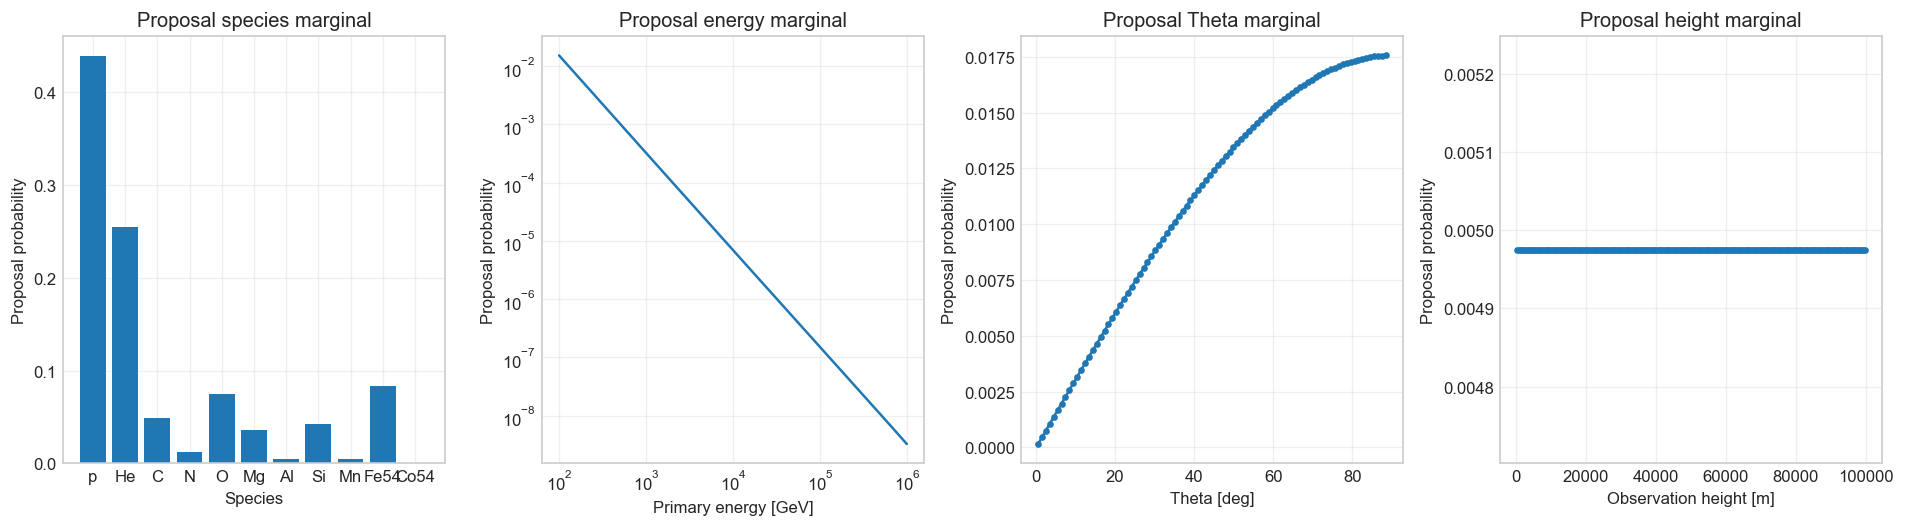

In [15]:
def build_sim_distribution(model: dict[str, Any], mode: str) -> dict[str, np.ndarray]:
    """Build the proposal distribution used for Monte Carlo sampling.

    Args:
        model: Loaded Run 1 model dictionary.
        mode: Sampling mode name.

    Returns:
        Proposal probabilities and CDFs for species-energy, theta, phi, and height.
    """
    real_se = model["species_energy_probability"]
    n_species, n_energy = real_se.shape
    if mode == "physical":
        sim_se = real_se.copy()
    elif mode == "balanced_log_energy":
        conditional = real_se / real_se.sum(axis=0, keepdims=True)
        sim_se = conditional * (np.ones(n_energy) / n_energy)[np.newaxis, :]
    elif mode == "balanced_log_energy_species":
        sim_se = np.ones((n_species, n_energy)) / (n_species * n_energy)
    else:
        raise ValueError(mode)
    sim_se /= sim_se.sum()
    sim_se_cdf = np.cumsum(sim_se.ravel())
    sim_se_cdf[-1] = 1.0
    return {
        "species_energy_probability_real": real_se,
        "species_energy_probability": sim_se,
        "species_energy_cdf": sim_se_cdf,
        "species_probability": model["species_probability"],
        "energy_probability": model["energy_probability"],
        "theta_probability": model["theta_probability"],
        "theta_cdf": model["theta_cdf"],
        "phi_probability": model["phi_probability"],
        "phi_cdf": model["phi_cdf"],
        "h_probability": model["h_probability"],
        "h_cdf": model["h_cdf"],
    }


SIM_DISTRIBUTION = build_sim_distribution(MODEL, CONFIG.sampling_mode)
print("Simulation distribution summary")
print("-" * 72)
print(f"Sampling mode:                  {CONFIG.sampling_mode}")
print(f"Species-energy probability sum: {SIM_DISTRIBUTION['species_energy_probability'].sum():.12f}")
print(f"Theta probability sum:          {SIM_DISTRIBUTION['theta_probability'].sum():.12f}")
print(f"Phi probability sum:            {SIM_DISTRIBUTION['phi_probability'].sum():.12f}")
print(f"Height probability sum:         {SIM_DISTRIBUTION['h_probability'].sum():.12f}")

species_probability = SIM_DISTRIBUTION["species_energy_probability"].sum(axis=1)
#species_probability = SIM_DISTRIBUTION["species_probability"]
energy_probability = SIM_DISTRIBUTION["species_energy_probability"].sum(axis=0)
#energy_probability = SIM_DISTRIBUTION["energy_probability"]
energy_centers = np.sqrt(MODEL["energy_edges"][:-1] * MODEL["energy_edges"][1:])
species_labels = [PRIMARY_SPECIES[int(cid)]["mnemonic"] for cid in MODEL["corsika_ids"]]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].bar(species_labels, species_probability)
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Proposal probability")
axes[0].set_title("Proposal species marginal")
axes[1].plot(energy_centers, energy_probability)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Primary energy [GeV]")
axes[1].set_ylabel("Proposal probability")
axes[1].set_title("Proposal energy marginal")
axes[2].plot(0.5 * (MODEL["theta_edges_deg"][:-1] + MODEL["theta_edges_deg"][1:]), SIM_DISTRIBUTION["theta_probability"], marker=".")
axes[2].set_xlabel("Theta [deg]")
axes[2].set_ylabel("Proposal probability")
axes[2].set_title("Proposal Theta marginal")
axes[3].plot(0.5 * (MODEL["h_edges_m"][:-1] + MODEL["h_edges_m"][1:]), SIM_DISTRIBUTION["h_probability"], marker=".")
axes[3].set_xlabel("Observation height [m]")
axes[3].set_ylabel("Proposal probability")
axes[3].set_title("Proposal height marginal")
plt.tight_layout()
plt.show()


In [16]:
# Subsection 4.1 diagnostic: verify proposal-distribution normalization.
assert np.isclose(SIM_DISTRIBUTION["species_energy_probability"].sum(), 1.0)
assert np.isclose(SIM_DISTRIBUTION["theta_probability"].sum(), 1.0)
assert np.isclose(SIM_DISTRIBUTION["phi_probability"].sum(), 1.0)
assert np.isclose(SIM_DISTRIBUTION["h_probability"].sum(), 1.0)
assert np.isclose(SIM_DISTRIBUTION["species_energy_cdf"][-1], 1.0)
print("Subsection 4.1 test passed: proposal distribution is normalized.")


Subsection 4.1 test passed: proposal distribution is normalized.


### 4.2. Sample Event Creation

This subsection samples the primary-event table from the already-built proposal distribution. The sample visualization routine is defined here so the same diagnostics can be reused after loading the stored primary file in Section 6.

[1/1] seed=877549497 -> crf_primary_877549497.csv (1000000 events)
Generated primary samples (seed=877549497)
------------------------------------------------------------------------
Rows:                 1000000
Weight sum:           3.690354e+01
Energy range [GeV]:   1.000e+02 to 2.584e+05
Theta range [deg]:    0.095 to 89.000
Height range [m]:     0.2 to 99999.8


,event_id,corsika_id,species_mnemonic,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,...,energy_bin_index,theta_bin_index,phi_bin_index,h_bin_index,p_real,q_sim,importance_ratio,primary_weight,sampling_mode,corsika8_primary_mode
0,0,14,p,1,1,2212,319.185706,63.683528,186.871252,93081.672321,...,126,64,187,187,2.045244e-10,2.045244e-10,1.0,0.000037,physical,pdg
1,1,1206,C,6,12,0,247.638350,67.774782,161.603936,80722.004393,...,98,68,162,162,3.711517e-11,3.711517e-11,1.0,0.000037,physical,nucleus
2,2,402,He,2,4,0,220.666802,41.620834,328.383806,3195.594452,...,86,42,329,6,1.685694e-10,1.685694e-10,1.0,0.000037,physical,nucleus
3,3,14,p,1,1,2212,367.168214,82.198035,232.479301,34601.638827,...,141,83,233,69,1.785388e-10,1.785388e-10,1.0,0.000037,physical,pdg
4,4,2814,Si,14,28,0,102.382679,47.199966,237.185344,15353.919274,...,2,47,237,30,1.171205e-10,1.171205e-10,1.0,0.000037,physical,nucleus


,E0_GeV,theta0_deg,observation_level_m,primary_weight,importance_ratio
count,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06
mean,248.636089,56.730379,49990.760841,3.690354e-05,1.000000e+00
std,884.068320,21.331120,28873.765412,7.525635e-20,2.746948e-16
min,100.000050,0.094766,0.219059,3.690354e-05,1.000000e+00
25%,118.773451,40.986969,24977.935606,3.690354e-05,1.000000e+00
50%,151.269348,59.441675,49992.653420,3.690354e-05,1.000000e+00
75%,228.837535,74.777382,75021.358391,3.690354e-05,1.000000e+00
max,258416.026968,88.999945,99999.800440,3.690354e-05,1.000000e+00


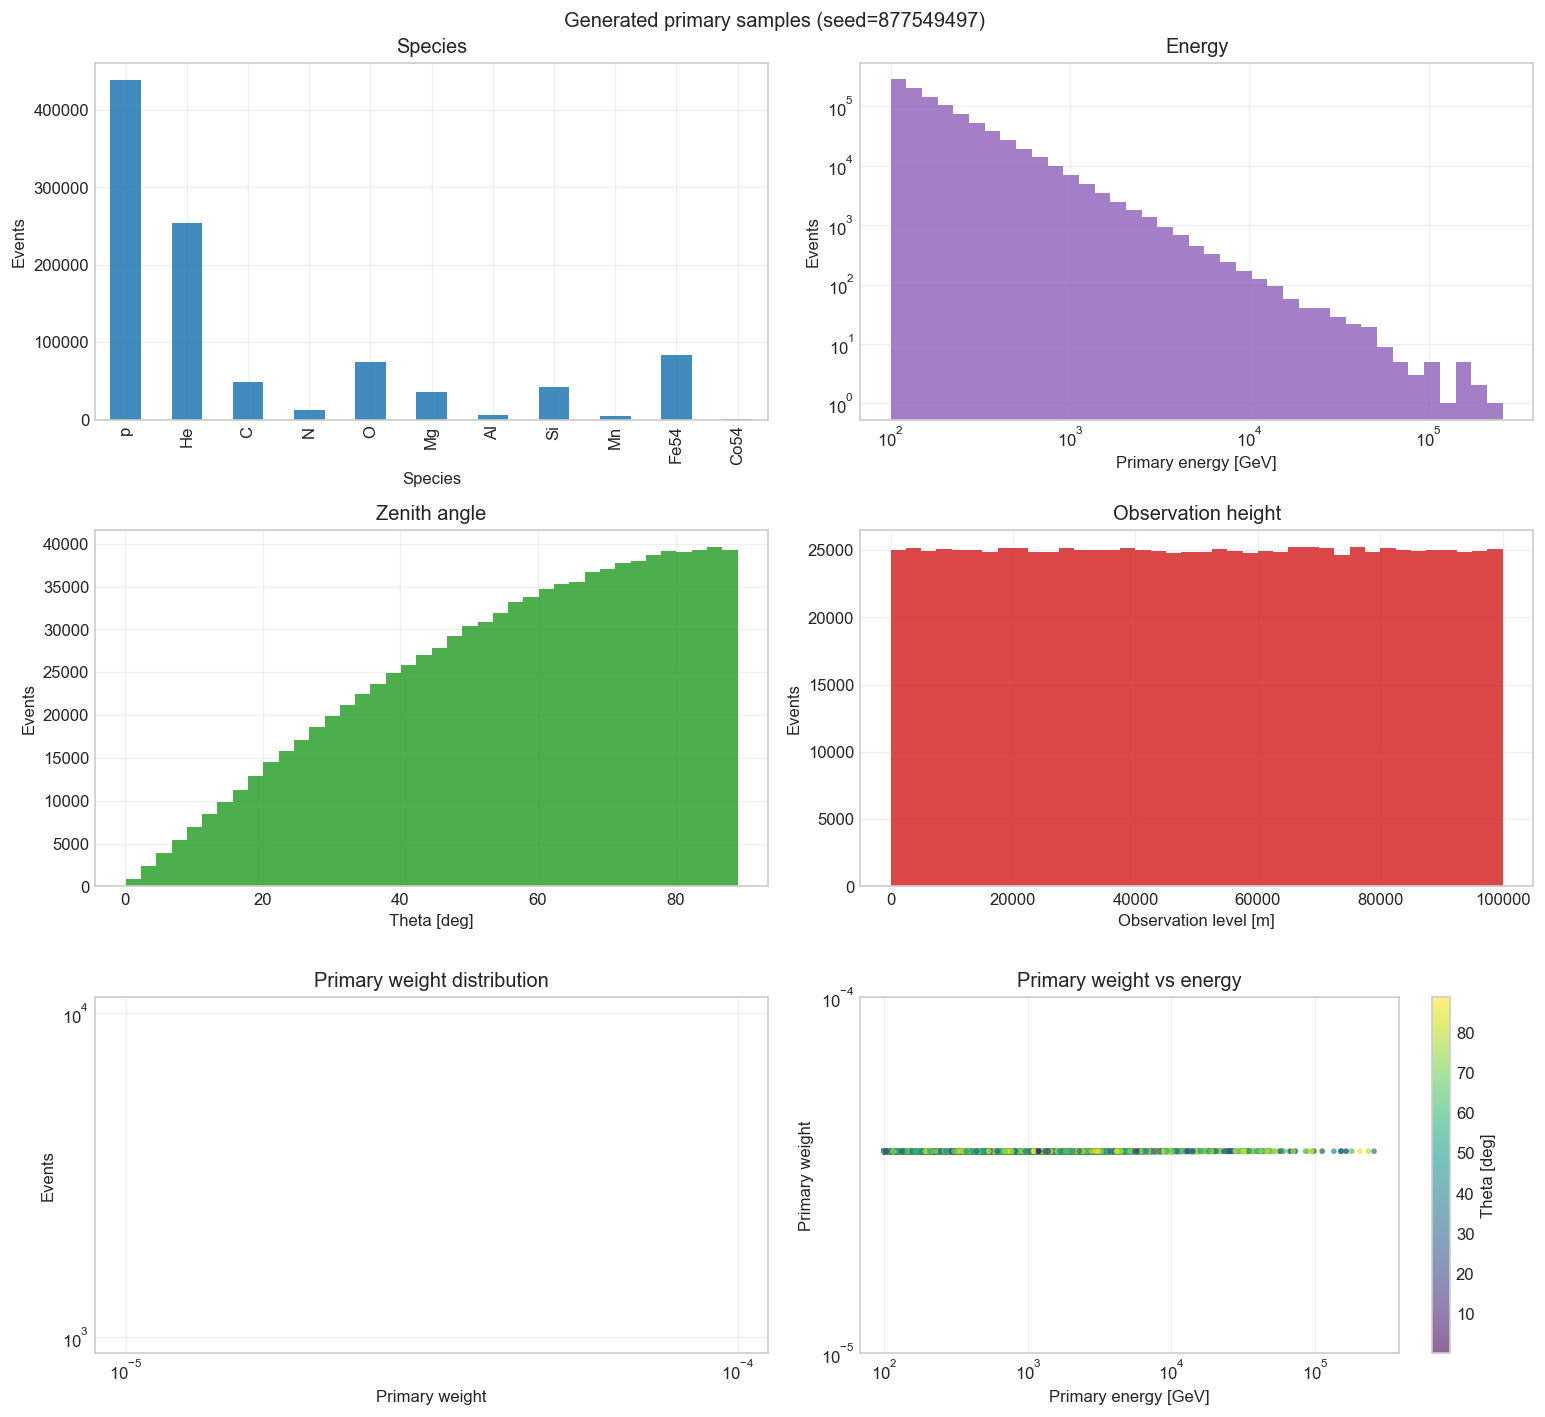

In [17]:
def corsika_id_to_nucleus(corsika_id: int) -> tuple[int, int]:
    """Convert a CORSIKA primary ID to nuclear charge and mass.

    Args:
        corsika_id: CORSIKA ID; proton is legacy ID 14 and nuclei use `100*A + Z`.

    Returns:
        Tuple `(Z, A)` with integer charge and mass number.
    """
    if int(corsika_id) == 14:
        return 1, 1
    return int(corsika_id) % 100, int(corsika_id) // 100


def sample_events(model: dict[str, Any], sim: dict[str, np.ndarray], config: SamplingConfig) -> pd.DataFrame:
    """Sample weighted CORSIKA primary events.

    Args:
        model: Loaded Run 1 model dictionary.
        sim: Proposal distribution returned by `build_sim_distribution`.
        config: Sampling configuration.

    Returns:
        DataFrame with one primary event per row and importance weights.
    """
    rng = np.random.default_rng(config.random_seed)
    n = config.n_events
    corsika_ids = model["corsika_ids"]
    energy_edges = model["energy_edges"]

    flat = np.searchsorted(sim["species_energy_cdf"], rng.random(n), side="right")
    species_idx, energy_idx = np.unravel_index(flat, sim["species_energy_probability"].shape)
    energy = np.exp(rng.uniform(np.log(energy_edges[energy_idx]), np.log(energy_edges[energy_idx + 1])))

    theta_idx = np.searchsorted(sim["theta_cdf"], rng.random(n), side="right")
    theta_edges = model["theta_edges_deg"]
    theta = np.rad2deg(np.arccos(rng.uniform(np.cos(np.deg2rad(theta_edges[theta_idx + 1])), np.cos(np.deg2rad(theta_edges[theta_idx])))))

    phi_idx = np.searchsorted(sim["phi_cdf"], rng.random(n), side="right")
    phi_edges = model["phi_edges_deg"]
    phi = rng.uniform(phi_edges[phi_idx], phi_edges[phi_idx + 1])

    h_idx = np.searchsorted(sim["h_cdf"], rng.random(n), side="right")
    h_edges = model["h_edges_m"]
    h = rng.uniform(h_edges[h_idx], h_edges[h_idx + 1])

    sampled_ids = corsika_ids[species_idx]
    z_values, a_values, pdg_values, modes, species_mnemonics = [], [], [], [], []
    for cid in sampled_ids:
        z, a = corsika_id_to_nucleus(int(cid))
        species = PRIMARY_SPECIES[int(cid)]
        z_values.append(z)
        a_values.append(a)
        pdg_values.append(int(species["pdg"]))
        modes.append("pdg" if (z, a) == (1, 1) else "nucleus")
        species_mnemonics.append(str(species["mnemonic"]))

    p_real = (
        model["species_energy_probability"][species_idx, energy_idx]
        * model["theta_probability"][theta_idx]
        * model["phi_probability"][phi_idx]
        * model["h_probability"][h_idx]
    )
    q_sim = (
        sim["species_energy_probability"][species_idx, energy_idx]
        * sim["theta_probability"][theta_idx]
        * sim["phi_probability"][phi_idx]
        * sim["h_probability"][h_idx]
    )
    ratio = p_real / q_sim
    primary_weight = model["cone_integrated_flux"] * ratio / n

    return pd.DataFrame({
        "event_id": np.arange(n, dtype=np.int64),
        "corsika_id": sampled_ids,
        "species_mnemonic": species_mnemonics,
        "Z": np.asarray(z_values, dtype=np.int32),
        "A": np.asarray(a_values, dtype=np.int32),
        "pdg": np.asarray(pdg_values, dtype=np.int32),
        "E0_GeV": energy,
        "theta0_deg": theta,
        "phi0_deg": phi,
        "observation_level_m": h,
        "species_index": species_idx,
        "energy_bin_index": energy_idx,
        "theta_bin_index": theta_idx,
        "phi_bin_index": phi_idx,
        "h_bin_index": h_idx,
        "p_real": p_real,
        "q_sim": q_sim,
        "importance_ratio": ratio,
        "primary_weight": primary_weight,
        "sampling_mode": config.sampling_mode,
        "corsika8_primary_mode": modes,
    })


def visualize_primary_samples(samples: pd.DataFrame, title: str = "Primary samples") -> None:
    """Print and plot a compact diagnostic summary of primary samples.

    Args:
        samples: Primary-event table to inspect.
        title: Title prefix for the diagnostic plots.

    Returns:
        None. The function prints summaries and displays histograms.
    """
    print(title)
    print("-" * 72)
    print(f"Rows:                 {len(samples)}")
    print(f"Weight sum:           {samples['primary_weight'].sum():.6e}")
    print(f"Energy range [GeV]:   {samples['E0_GeV'].min():.3e} to {samples['E0_GeV'].max():.3e}")
    print(f"Theta range [deg]:    {samples['theta0_deg'].min():.3f} to {samples['theta0_deg'].max():.3f}")
    print(f"Height range [m]:     {samples['observation_level_m'].min():.1f} to {samples['observation_level_m'].max():.1f}")
    display(samples.head())
    display(samples[["E0_GeV", "theta0_deg", "observation_level_m", "primary_weight", "importance_ratio"]].describe())

    fig, axes = plt.subplots(3, 2, figsize=(13, 12))
    species_counts = samples["species_mnemonic"].value_counts().reindex(
        [PRIMARY_SPECIES[int(cid)]["mnemonic"] for cid in MODEL["corsika_ids"]], fill_value=0
    )
    species_counts.plot(kind="bar", ax=axes[0, 0], color="tab:blue", alpha=0.85)
    axes[0, 0].set_xlabel("Species")
    axes[0, 0].set_ylabel("Events")
    axes[0, 0].set_title("Species")

    energy_bins = np.logspace(np.log10(samples["E0_GeV"].min()), np.log10(samples["E0_GeV"].max()), 40)
    axes[0, 1].hist(samples["E0_GeV"], bins=energy_bins, color="tab:purple", alpha=0.85)
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xlabel("Primary energy [GeV]")
    axes[0, 1].set_ylabel("Events")
    axes[0, 1].set_title("Energy")

    axes[1, 0].hist(samples["theta0_deg"], bins=40, color="tab:green", alpha=0.85)
    axes[1, 0].set_xlabel("Theta [deg]")
    axes[1, 0].set_ylabel("Events")
    axes[1, 0].set_title("Zenith angle")

    axes[1, 1].hist(samples["observation_level_m"], bins=40, color="tab:red", alpha=0.85)
    axes[1, 1].set_xlabel("Observation level [m]")
    axes[1, 1].set_ylabel("Events")
    axes[1, 1].set_title("Observation height")

    positive_weights = samples.loc[samples["primary_weight"] > 0, "primary_weight"]
    if len(positive_weights) > 1 and positive_weights.min() < positive_weights.max():
        weight_bins = np.logspace(np.log10(positive_weights.min()), np.log10(positive_weights.max()), 40)
    else:
        weight_bins = 40
    axes[2, 0].hist(positive_weights, bins=weight_bins, color="tab:orange", alpha=0.85)
    axes[2, 0].set_xscale("log")
    axes[2, 0].set_yscale("log")
    axes[2, 0].set_xlabel("Primary weight")
    axes[2, 0].set_ylabel("Events")
    axes[2, 0].set_title("Primary weight distribution")

    scatter = axes[2, 1].scatter(
        samples["E0_GeV"],
        samples["primary_weight"],
        c=samples["theta0_deg"],
        s=6,
        alpha=0.6,
        cmap="viridis",
    )
    axes[2, 1].set_xscale("log")
    axes[2, 1].set_yscale("log")
    axes[2, 1].set_xlabel("Primary energy [GeV]")
    axes[2, 1].set_ylabel("Primary weight")
    axes[2, 1].set_title("Primary weight vs energy")
    fig.colorbar(scatter, ax=axes[2, 1], label="Theta [deg]")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


primary_runs = []
for file_index, seed in enumerate(RANDOM_SEEDS, start=1):
    run_output_path = PATH_OUTPUT_RUN / f"crf_primary_{seed}.csv"
    run_config = replace(CONFIG, random_seed=seed, output_path=run_output_path)
    run_primaries = sample_events(MODEL, SIM_DISTRIBUTION, run_config)
    primary_runs.append({"seed": seed, "config": run_config, "primaries": run_primaries})
    print(f"[{file_index}/{len(RANDOM_SEEDS)}] seed={seed} -> {run_output_path.name} ({len(run_primaries)} events)")

visualize_primary_samples(
    primary_runs[0]["primaries"],
    title=f"Generated primary samples (seed={primary_runs[0]['seed']})",
)



In [18]:
# Subsection 4.2 diagnostic: verify generated primary-event columns and ranges.
required_columns = {
    "event_id", "corsika_id", "species_mnemonic", "E0_GeV", "theta0_deg",
    "phi0_deg", "observation_level_m", "primary_weight", "importance_ratio",
}
assert len(primary_runs) == N_PRIMARY_FILES
for run in primary_runs:
    run_primaries = run["primaries"]
    assert required_columns.issubset(run_primaries.columns)
    assert len(run_primaries) == run["config"].n_events
    assert np.all(run_primaries["E0_GeV"] > 0.0)
    assert np.all(run_primaries["primary_weight"] >= 0.0)
print(f"Subsection 4.2 test passed: {len(primary_runs)} primary sample file(s) generated successfully.")



Subsection 4.2 test passed: 1 primary sample file(s) generated successfully.


## 5. File Storage

This section stores the generated primary table using the configured file format. CSV is convenient for inspection, while Parquet is more efficient for large campaigns.

In [19]:
for run in primary_runs:
    run_config = run["config"]
    run_config.output_directory.mkdir(parents=True, exist_ok=True)
    if run_config.output_format == "csv":
        run["primaries"].to_csv(run_config.output_path, index=False, float_format="%.12e")
    else:
        run["primaries"].to_parquet(run_config.output_path, index=False)
    print(f"Saved: {run_config.output_path}")


Saved: v:\output\data\crf\generator\run_test\crf_primary_877549497.csv


In [20]:
# Section 5 diagnostic: verify every stored file exists and is non-empty.
for run in primary_runs:
    output_path = run["config"].output_path
    exists = output_path.exists()
    size = output_path.stat().st_size if exists else 0
    print(f"{output_path.name:<40} exists={exists}  size={size} bytes")
    assert exists
    assert size > 0



crf_primary_877549497.csv                exists=True  size=204593237 bytes


## 6. Primary File Loading and Sample Visualization

This section reloads the stored primary table and visualizes key sampled variables to confirm that the file is readable and the sampled ranges look consistent.

Reloaded primary samples (file 1/1, seed=877549497)
------------------------------------------------------------------------
Rows:                 1000000
Weight sum:           3.690354e+01
Energy range [GeV]:   1.000e+02 to 2.584e+05
Theta range [deg]:    0.095 to 89.000
Height range [m]:     0.2 to 99999.8


,event_id,corsika_id,species_mnemonic,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,...,energy_bin_index,theta_bin_index,phi_bin_index,h_bin_index,p_real,q_sim,importance_ratio,primary_weight,sampling_mode,corsika8_primary_mode
0,0,14,p,1,1,2212,319.185706,63.683528,186.871252,93081.672321,...,126,64,187,187,2.045244e-10,2.045244e-10,1.0,0.000037,physical,pdg
1,1,1206,C,6,12,0,247.638350,67.774782,161.603936,80722.004393,...,98,68,162,162,3.711517e-11,3.711517e-11,1.0,0.000037,physical,nucleus
2,2,402,He,2,4,0,220.666802,41.620834,328.383806,3195.594452,...,86,42,329,6,1.685694e-10,1.685694e-10,1.0,0.000037,physical,nucleus
3,3,14,p,1,1,2212,367.168214,82.198035,232.479301,34601.638827,...,141,83,233,69,1.785388e-10,1.785388e-10,1.0,0.000037,physical,pdg
4,4,2814,Si,14,28,0,102.382679,47.199966,237.185344,15353.919274,...,2,47,237,30,1.171205e-10,1.171205e-10,1.0,0.000037,physical,nucleus


,E0_GeV,theta0_deg,observation_level_m,primary_weight,importance_ratio
count,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.0
mean,248.636089,56.730379,49990.760841,3.690354e-05,1.0
std,884.068320,21.331120,28873.765412,3.388133e-20,0.0
min,100.000050,0.094766,0.219059,3.690354e-05,1.0
25%,118.773451,40.986969,24977.935606,3.690354e-05,1.0
50%,151.269348,59.441675,49992.653420,3.690354e-05,1.0
75%,228.837535,74.777382,75021.358391,3.690354e-05,1.0
max,258416.026968,88.999945,99999.800440,3.690354e-05,1.0


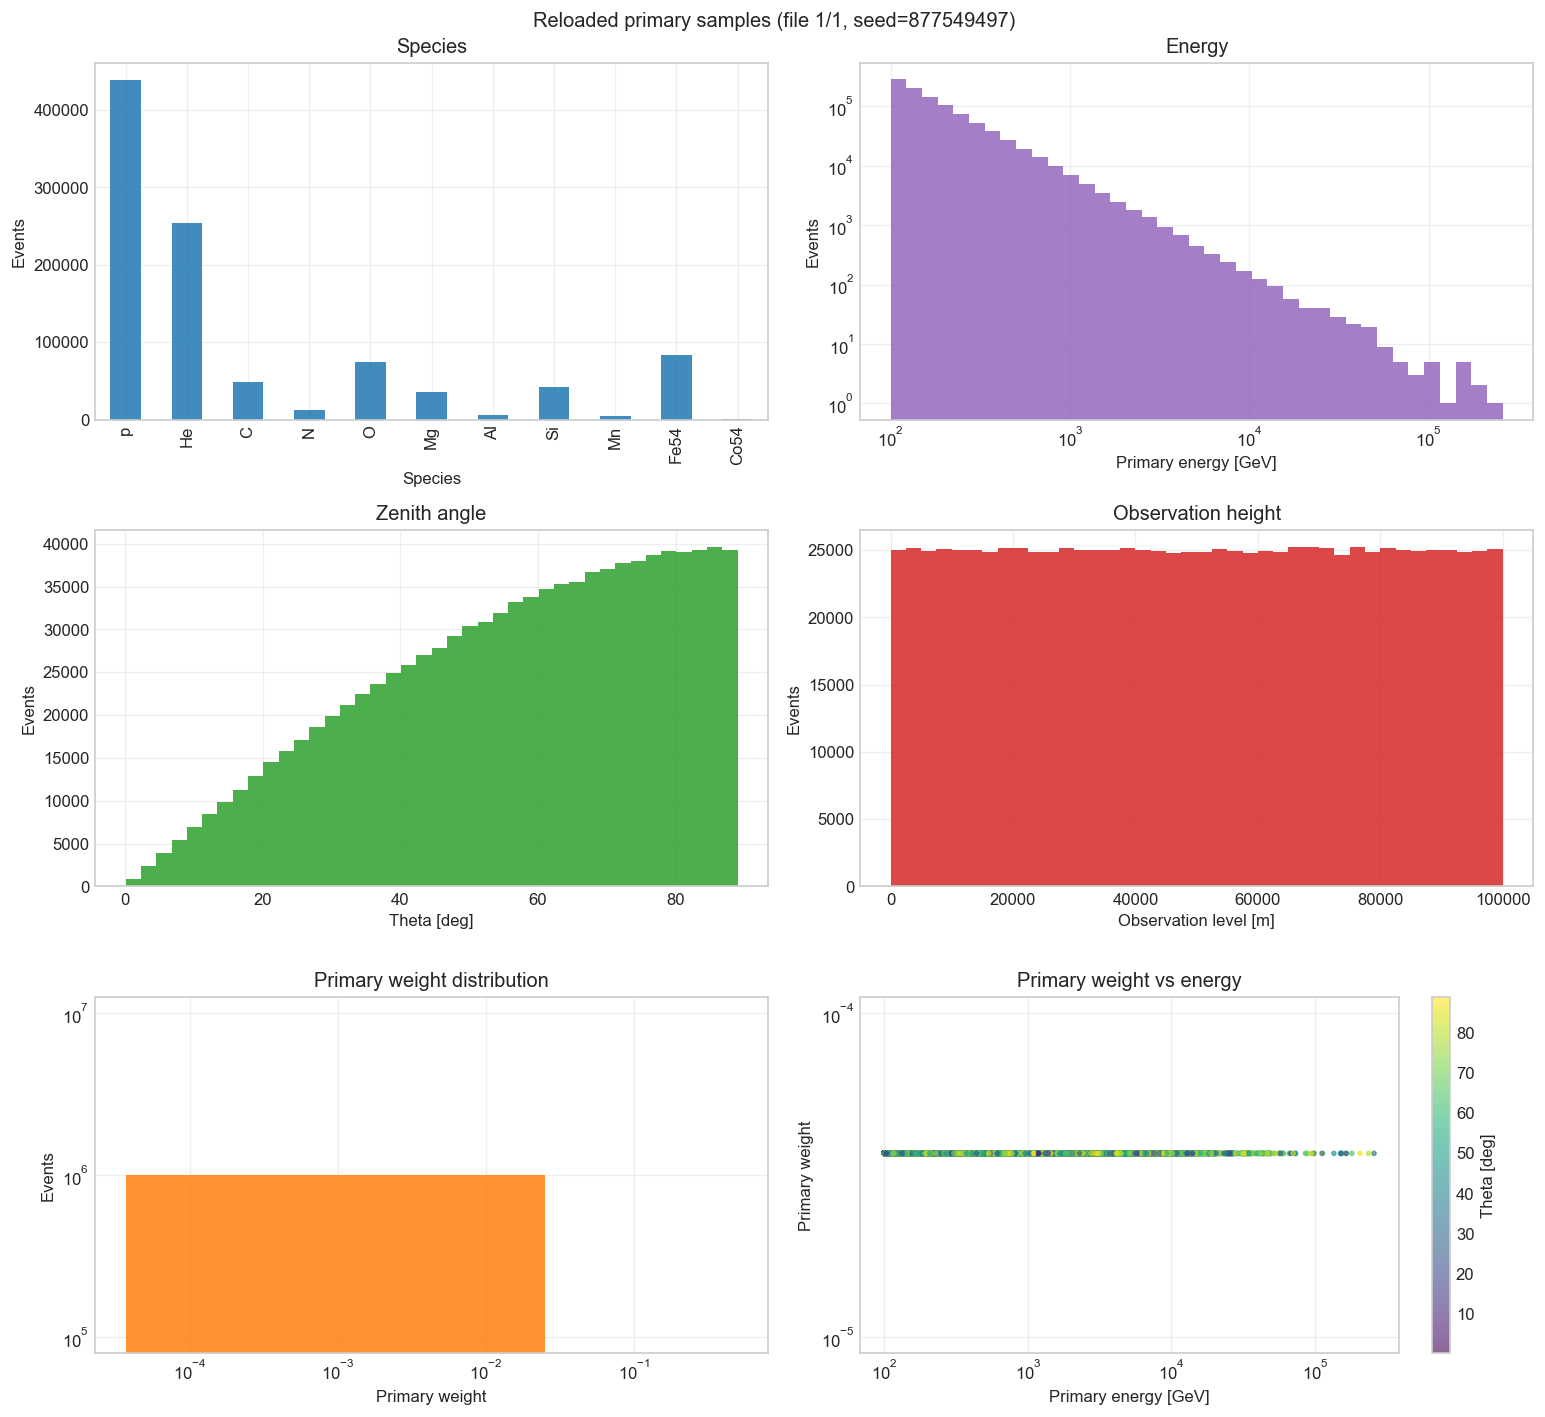

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   event_id               1000000 non-null  int64  
 1   corsika_id             1000000 non-null  int64  
 2   species_mnemonic       1000000 non-null  object 
 3   Z                      1000000 non-null  int64  
 4   A                      1000000 non-null  int64  
 5   pdg                    1000000 non-null  int64  
 6   E0_GeV                 1000000 non-null  float64
 7   theta0_deg             1000000 non-null  float64
 8   phi0_deg               1000000 non-null  float64
 9   observation_level_m    1000000 non-null  float64
 10  species_index          1000000 non-null  int64  
 11  energy_bin_index       1000000 non-null  int64  
 12  theta_bin_index        1000000 non-null  int64  
 13  phi_bin_index          1000000 non-null  int64  
 14  h_bin_index        

In [21]:
_reload_config = primary_runs[0]["config"]
loaded = (
    pd.read_csv(_reload_config.output_path)
    if _reload_config.output_format == "csv"
    else pd.read_parquet(_reload_config.output_path)
)
visualize_primary_samples(
    loaded,
    title=f"Reloaded primary samples (file 1/{len(primary_runs)}, seed={_reload_config.random_seed})",
)
print(loaded.info())
print(len(loaded[loaded['Z']==26]))


In [22]:
print(loaded.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   event_id               1000000 non-null  int64  
 1   corsika_id             1000000 non-null  int64  
 2   species_mnemonic       1000000 non-null  object 
 3   Z                      1000000 non-null  int64  
 4   A                      1000000 non-null  int64  
 5   pdg                    1000000 non-null  int64  
 6   E0_GeV                 1000000 non-null  float64
 7   theta0_deg             1000000 non-null  float64
 8   phi0_deg               1000000 non-null  float64
 9   observation_level_m    1000000 non-null  float64
 10  species_index          1000000 non-null  int64  
 11  energy_bin_index       1000000 non-null  int64  
 12  theta_bin_index        1000000 non-null  int64  
 13  phi_bin_index          1000000 non-null  int64  
 14  h_bin_index        